   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 733.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 20.7 MB/s eta 0:00:00
1. DOWNLOADING DATASET
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
✅ Dataset path: /kaggle/input/ocular-disease-recognition-odir5k

Dataset Shape: (6392, 19)
Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']

2. BASIC DEMOGRAPHICS & LABELS


/tmp/ipython-input-740201053.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


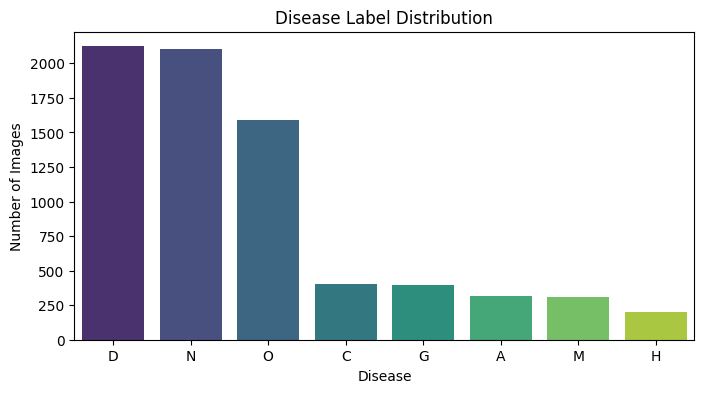

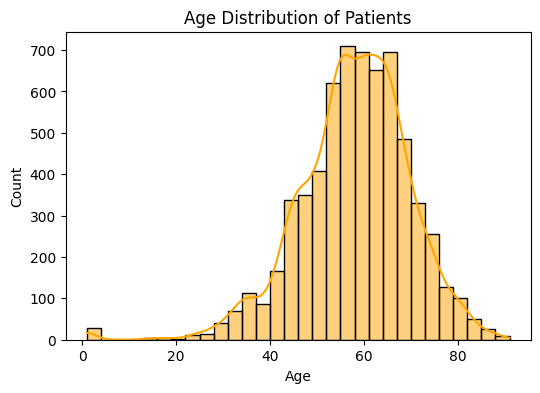

/tmp/ipython-input-740201053.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Patient Sex", data=df, palette='pastel')


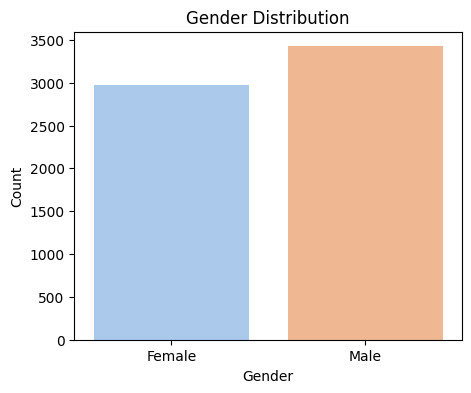


3. LOCATING IMAGE DIRECTORY
✅ Images found at: /kaggle/input/ocular-disease-recognition-odir5k/preprocessed_images

4. SAMPLE PATIENT SCANS


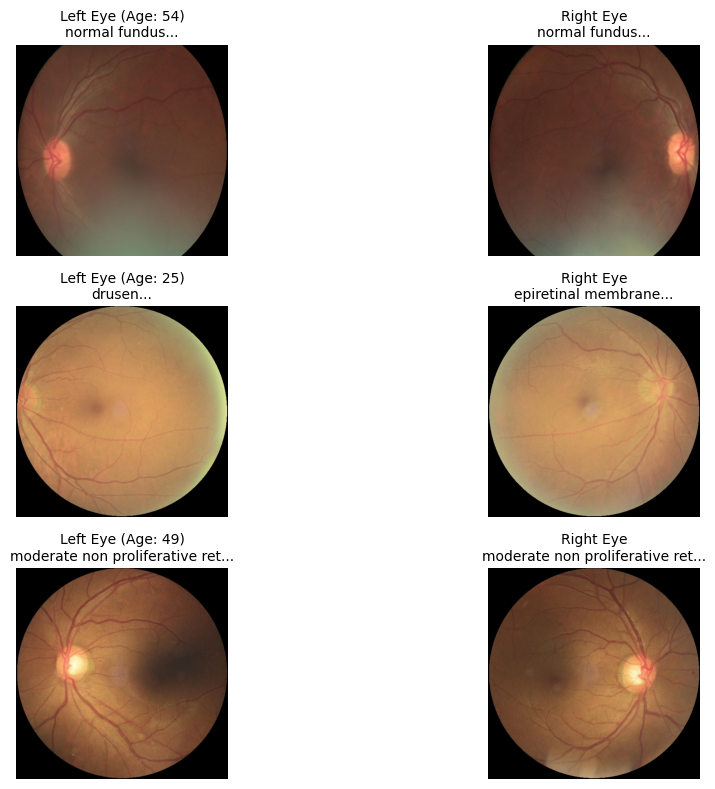


5. INTEGRITY CHECK (Missing/Corrupt)
Checking integrity of first 500 images...


100%|██████████| 500/500 [00:02<00:00, 236.08it/s]



✅ Integrity Report (Sample n=500):
   - Valid:     450
   - Missing:   50
   - Corrupted: 0

6. COLOR CHANNEL ANALYSIS (RGB)


Calculating Histograms: 100%|██████████| 100/100 [00:00<00:00, 134.67it/s]


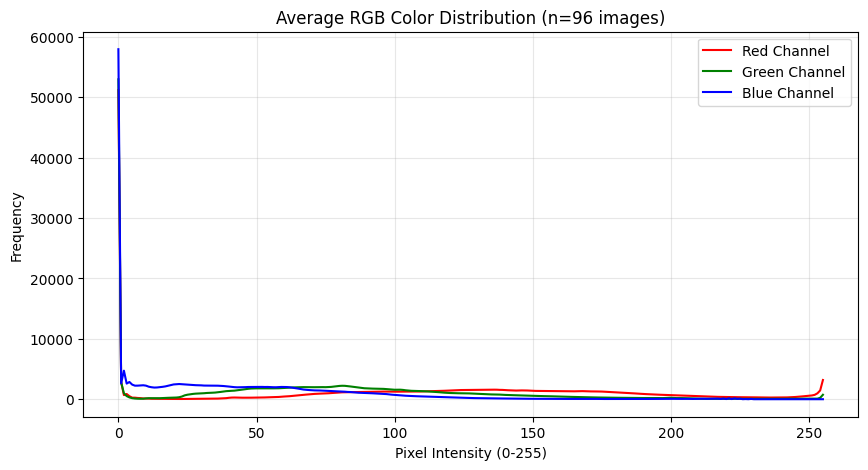


       DATASET DIAGNOSTIC REPORT
1. HEALTH CHECK
   - Total Images:      12784 (Left + Right)
   - Unique Patients:   3358
   - Duplicates:        3034
   - Missing Labels:    0

2. DEEP STATS
   - Most Common Res:   512x512 (197 samples)
   - Avg Brightness:    78.78 (Target: ~100-150)
   - Avg Diseases/Pt:   1.16

3. IMBALANCE ANALYSIS
   📉 Minority Class: 'Hypertension' (203)
   📈 Majority Class: 'Diabetes' (2123)
   ⚖️ Imbalance Ratio: 1 : 10.46
   ⚠️ STATUS: CRITICAL. Suggestion: Must use Class Weights AND Oversampling

4. DETAILED STATS
 ID  | Class Name      | Count    | %     
---------------------------------------------
 D   | Diabetes        | 2123     | 28.5%
 N   | Normal          | 2101     | 28.2%
 O   | Other           | 1588     | 21.3%
 C   | Cataract        | 402      | 5.4%
 G   | Glaucoma        | 397      | 5.3%
 A   | AMD             | 319      | 4.3%
 M   | Myopia          | 306      | 4.1%
 H   | Hypertension    | 203      | 2.7%

8. IMAGE CLEANING & PREPROCES

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


✅ Images after cleaning: 6232
✅ Dataset cleaned, resized, and normalized
Final dataset size: 6232

REMOVING DUPLICATE RECORDS
Initial rows: 6392
Rows after duplicate removal: 3358
Duplicates removed: 3034


In [ ]:
# ==============================================================================
# ODIR-5K COMPLETE EDA (Unified Script)
# ==============================================================================

# 1. INSTALL & IMPORTS
# ------------------------------------------------------------------------------
!pip install kagglehub seaborn matplotlib pandas numpy opencv-python tqdm tensorflow --quiet

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from collections import Counter

# ==============================================================================
# 2. DATASET SETUP & BASIC STATS
# ==============================================================================
print(f"{'='*40}\n1. DOWNLOADING DATASET\n{'='*40}")
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print("✅ Dataset path:", path)

# Load CSV
csv_path = os.path.join(path, "full_df.csv")
if not os.path.exists(csv_path):
    raise FileNotFoundError("Could not find full_df.csv")

df = pd.read_csv(csv_path)
print("\nDataset Shape:", df.shape)
print(f"Columns: {list(df.columns)}")

# --- Basic Visualizations ---
print(f"\n{'='*40}\n2. BASIC DEMOGRAPHICS & LABELS\n{'='*40}")

# Disease Label Distribution
labels = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
label_counts = df[labels].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title("Disease Label Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Patient Age"], bins=30, kde=True, color='orange')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Gender Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Patient Sex", data=df, palette='pastel')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ==============================================================================
# 3. LOCATE IMAGE DIRECTORY
# ==============================================================================
print(f"\n{'='*40}\n3. LOCATING IMAGE DIRECTORY\n{'='*40}")
image_dir = None
search_paths = [
    os.path.join(path, "preprocessed_images"),
    os.path.join(path, "ODIR-5K", "Training Images"),
    os.path.join(path, "ODIR-5K", "ODIR-5K", "Training Images")
]

for p in search_paths:
    if os.path.exists(p) and len(os.listdir(p)) > 0:
        image_dir = p
        break

# Fallback search
if not image_dir:
    for root, dirs, files in os.walk(path):
        if "0_left.jpg" in files:
            image_dir = root
            break

if image_dir:
    print(f"✅ Images found at: {image_dir}")
else:
    print("❌ Could not locate images. Please check the download path.")

# ==============================================================================
# 4. SAMPLE IMAGE VISUALIZATION
# ==============================================================================
if image_dir:
    print(f"\n{'='*40}\n4. SAMPLE PATIENT SCANS\n{'='*40}")
    samples = df.sample(3)

    plt.figure(figsize=(12, 8))
    for idx, (i, row) in enumerate(samples.iterrows()):
        l_path = os.path.join(image_dir, row['Left-Fundus'])
        r_path = os.path.join(image_dir, row['Right-Fundus'])

        # Plot Left Eye
        plt.subplot(3, 2, idx*2 + 1)
        if os.path.exists(l_path):
            plt.imshow(Image.open(l_path))
            plt.title(f"Left Eye (Age: {row['Patient Age']})\n{row['Left-Diagnostic Keywords'][:30]}...", fontsize=10)
        else:
            plt.text(0.5, 0.5, "Missing", ha='center')
        plt.axis('off')

        # Plot Right Eye
        plt.subplot(3, 2, idx*2 + 2)
        if os.path.exists(r_path):
            plt.imshow(Image.open(r_path))
            plt.title(f"Right Eye\n{row['Right-Diagnostic Keywords'][:30]}...", fontsize=10)
        else:
            plt.text(0.5, 0.5, "Missing", ha='center')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 5. INTEGRITY CHECK (MISSING/CORRUPT)
# ==============================================================================
if image_dir:
    print(f"\n{'='*40}\n5. INTEGRITY CHECK (Missing/Corrupt)\n{'='*40}")
    missing_files = []
    corrupted_files = []

    # Check all files listed in the CSV
    all_images = pd.concat([df['Left-Fundus'], df['Right-Fundus']]).dropna().unique()

    # We check the first 500 for speed (remove [:500] to check all)
    check_limit = 500
    print(f"Checking integrity of first {check_limit} images...")

    for filename in tqdm(all_images[:check_limit]):
        file_path = os.path.join(image_dir, filename)

        if not os.path.exists(file_path):
            missing_files.append(filename)
        else:
            try:
                # Try opening to check for corruption
                with Image.open(file_path) as img:
                    img.verify()
            except:
                corrupted_files.append(filename)

    print(f"\n✅ Integrity Report (Sample n={check_limit}):")
    print(f"   - Valid:     {check_limit - len(missing_files) - len(corrupted_files)}")
    print(f"   - Missing:   {len(missing_files)}")
    print(f"   - Corrupted: {len(corrupted_files)}")

# ==============================================================================
# 6. COLOR CHANNEL ANALYSIS
# ==============================================================================
if image_dir:
    print(f"\n{'='*40}\n6. COLOR CHANNEL ANALYSIS (RGB)\n{'='*40}")
    # We analyze a sample of 100 images to save time
    sample_files = df['Left-Fundus'].sample(100).values

    r_avg, g_avg, b_avg = np.zeros(256), np.zeros(256), np.zeros(256)
    count = 0

    for fname in tqdm(sample_files, desc="Calculating Histograms"):
        fpath = os.path.join(image_dir, fname)
        if os.path.exists(fpath):
            img = cv2.imread(fpath)
            if img is not None:
                # Convert BGR (OpenCV default) to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Calculate histograms for each channel
                r_hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
                g_hist = cv2.calcHist([img], [1], None, [256], [0, 256]).flatten()
                b_hist = cv2.calcHist([img], [2], None, [256], [0, 256]).flatten()

                r_avg += r_hist
                g_avg += g_hist
                b_avg += b_hist
                count += 1

    # Plotting
    if count > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(r_avg / count, color='red', label='Red Channel')
        plt.plot(g_avg / count, color='green', label='Green Channel')
        plt.plot(b_avg / count, color='blue', label='Blue Channel')
        plt.title(f"Average RGB Color Distribution (n={count} images)")
        plt.xlabel("Pixel Intensity (0-255)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# ==============================================================================
# 7. GENERATE DATASET DIAGNOSTIC REPORT
# ==============================================================================
print(f"\n{'='*50}")
print("       DATASET DIAGNOSTIC REPORT")
print(f"{'='*50}")

# --- 1. HEALTH CHECK ---
total_rows = len(df)
total_images = total_rows * 2  # Left + Right
unique_patients = df['ID'].nunique() if 'ID' in df.columns else total_rows
duplicates = total_rows - unique_patients
target_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
missing_labels = df[target_cols].isnull().any(axis=1).sum()

print("1. HEALTH CHECK")
print(f"   - Total Images:      {total_images} (Left + Right)")
print(f"   - Unique Patients:   {unique_patients}")
print(f"   - Duplicates:        {duplicates}")
print(f"   - Missing Labels:    {missing_labels}")
print("")

# --- 2. DEEP STATS ---
if image_dir:
    # Use the sample stats we calculated earlier or scan new ones if needed
    resolutions = []
    brightness_vals = []
    # Scan 200 random images
    sample_scan = df['Left-Fundus'].sample(n=min(200, len(df))).values

    for fname in sample_scan:
        fpath = os.path.join(image_dir, fname)
        if os.path.exists(fpath):
            img = cv2.imread(fpath)
            if img is not None:
                h, w, _ = img.shape
                resolutions.append(f"{w}x{h}")
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                brightness_vals.append(gray.mean())

    if resolutions:
        most_common_res = Counter(resolutions).most_common(1)[0]
        res_str = f"{most_common_res[0]} ({most_common_res[1]} samples)"
        avg_bright = np.mean(brightness_vals)
    else:
        res_str = "N/A"
        avg_bright = 0.0
else:
    res_str = "Image Dir Not Found"
    avg_bright = 0.0

avg_diseases = df[target_cols].sum(axis=1).mean()

print("2. DEEP STATS")
print(f"   - Most Common Res:   {res_str}")
print(f"   - Avg Brightness:    {avg_bright:.2f} (Target: ~100-150)")
print(f"   - Avg Diseases/Pt:   {avg_diseases:.2f}")
print("")

# --- 3. IMBALANCE ANALYSIS ---
class_map = {
    'N': 'Normal', 'D': 'Diabetes', 'G': 'Glaucoma', 'C': 'Cataract',
    'A': 'AMD', 'H': 'Hypertension', 'M': 'Myopia', 'O': 'Other'
}
counts = df[target_cols].sum().sort_values(ascending=False)
maj_class_code = counts.index[0]
min_class_code = counts.index[-1]
maj_count = counts.iloc[0]
min_count = counts.iloc[-1]
ratio = maj_count / min_count if min_count > 0 else 0

if ratio > 10:
    status = "CRITICAL"
    suggestion = "Must use Class Weights AND Oversampling"
elif ratio > 3:
    status = "HIGH"
    suggestion = "Use Class Weights"
else:
    status = "BALANCED"
    suggestion = "None"

print("3. IMBALANCE ANALYSIS")
print(f"   📉 Minority Class: '{class_map[min_class_code]}' ({min_count})")
print(f"   📈 Majority Class: '{class_map[maj_class_code]}' ({maj_count})")
print(f"   ⚖️ Imbalance Ratio: 1 : {ratio:.2f}")
print(f"   ⚠️ STATUS: {status}. Suggestion: {suggestion}")
print("")

# --- 4. DETAILED STATS ---
print("4. DETAILED STATS")
print(f" {'ID':<3} | {'Class Name':<15} | {'Count':<8} | {'%':<6}")
print("-" * 45)

total_labels = counts.sum()
for code, count in counts.items():
    name = class_map[code]
    pct = (count / total_labels) * 100
    print(f" {code:<3} | {name:<15} | {count:<8} | {pct:.1f}%")

# ==============================================================================
# 8. CLEANING, RESIZING & NORMALIZATION FOR EFFICIENTNET-B3
# ==============================================================================

print(f"\n{'='*40}\n8. IMAGE CLEANING & PREPROCESSING\n{'='*40}")

import tensorflow as tf

IMG_SIZE = 300   # EfficientNetB3 input size
TARGET_LABELS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

# ------------------------------------------------------------------
# STEP 1: CLEAN DATA (remove missing image files)
# ------------------------------------------------------------------
df_clean = df.dropna(subset=['Left-Fundus']).copy()

df_clean['image_path'] = df_clean['Left-Fundus'].apply(
    lambda x: os.path.join(image_dir, x)
)

# Keep only existing image files
df_clean = df_clean[df_clean['image_path'].apply(os.path.exists)]

print("✅ Images after cleaning:", len(df_clean))

# Extract paths and labels
X = df_clean['image_path'].values
y = df_clean[TARGET_LABELS].values.astype('float32')

# ------------------------------------------------------------------
# STEP 2: IMAGE LOAD, RESIZE & NORMALIZE (EfficientNetB3)
# ------------------------------------------------------------------
def preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

# ------------------------------------------------------------------
# STEP 3: BUILD TF.DATA PIPELINE
# ------------------------------------------------------------------
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

print("✅ Dataset cleaned, resized, and normalized")
print("Final dataset size:", len(X))

# ==============================================================================
# REMOVE DUPLICATE RECORDS FROM ODIR-5K
# ==============================================================================

print(f"\n{'='*40}\nREMOVING DUPLICATE RECORDS\n{'='*40}")

# Initial dataset size
initial_rows = len(df)
print("Initial rows:", initial_rows)

# Remove duplicate patient records based on Patient ID
if 'ID' in df.columns:
    df = df.drop_duplicates(subset=['ID'], keep='first')
else:
    # Fallback: remove fully duplicated rows
    df = df.drop_duplicates()

final_rows = len(df)

print("Rows after duplicate removal:", final_rows)
print("Duplicates removed:", initial_rows - final_rows)
